# Excitons from the Bethe-Salpeter equation
A mean-field band structure can only absorb above its gap, but the electron and the hole that
absorbing a photon creates attract each other, the pair binds, and the bound state, the exciton,
appears below the gap by its binding energy. `h.get_bse()` solves the Bethe-Salpeter equation on
top of a mean-field Hamiltonian, diagonalizing the electron-hole pair Hamiltonian directly, in its
full non-Tamm-Dancoff form and at any center-of-mass momentum $Q$. The exciton at momentum $Q$ is a
superposition of the transitions of the mean field,

$$|X\rangle_Q = \sum_{v,c,k} A_{vc}(k)\, c^\dagger_{c,k+Q} c_{v,k} |MF\rangle$$

and the solution gives the exciton energies, their binding energies, and the electron-hole
amplitudes $A_{vc}(k)$ that say what each exciton is made of. Scanning $Q$ along a path gives the
exciton band structure. By default the interaction is the one the mean field was converged with,
so the calculation is time-dependent Hartree-Fock on top of Hartree-Fock; a long-ranged
interaction can be passed with `V=`.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.bsetk.interaction import density_interaction

### Excitons on top of a mean field
Let us converge a gapped honeycomb lattice with an onsite $U$ and a first-neighbor $V_1$, and ask
for its lowest excitons. The interaction of the kernel is read off the mean-field Hamiltonian, so
the same interaction that generated the self-energy also generates the electron-hole attraction,
and nothing is double counted. The binding energy is how far each exciton lies below the lowest
independent-particle transition, positive meaning bound. Here it is the neighbor-shell $V_1$ that
binds them: with the onsite $U$ alone the binding energy comes out zero, since an onsite
interaction is too short ranged to bind an exciton in two dimensions.

In [2]:
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=True)
h.add_sublattice_imbalance(0.6) # a gapped reference
hmf = h.get_mean_field_hamiltonian(U=1.5,V1=0.5,filling=0.5,mf="imbalance",nk=6) # converge a mean field
bse = hmf.get_bse(nk=6) # solve the BSE with the interaction of the mean field
print("lowest independent-particle transition = %.4f"%bse.get_lowest_transition())
for (e,eb) in zip(bse.get_energies(n=4),bse.get_binding_energies(n=4)):
    print("exciton energy = %.4f   binding energy = %.4f"%(np.real(e),np.real(eb)))

lowest independent-particle transition = 2.0140
exciton energy = 1.9604   binding energy = 0.0536
exciton energy = 1.9604   binding energy = 0.0536
exciton energy = 1.9604   binding energy = 0.0536
exciton energy = 1.9604   binding energy = 0.0536


### The electron-hole amplitudes over the Brillouin zone
For a Wannier-Mott exciton the interaction has to be long ranged, so let us now take a gapped
honeycomb semiconductor with a Coulomb tail, built with `density_interaction` and passed with
`V=`, and look at what its lowest exciton is made of. The amplitude $|A(k)|^2$,
summed over the valence and conduction bands, says which k-points the exciton is built from. At
weak coupling it sits on the K and K' valleys, where the gap is smallest; as the interaction grows
the exciton binds more strongly, shrinks in real space and spreads over the Brillouin zone. The
white hexagon is the first Brillouin zone, with the valleys at its corners.

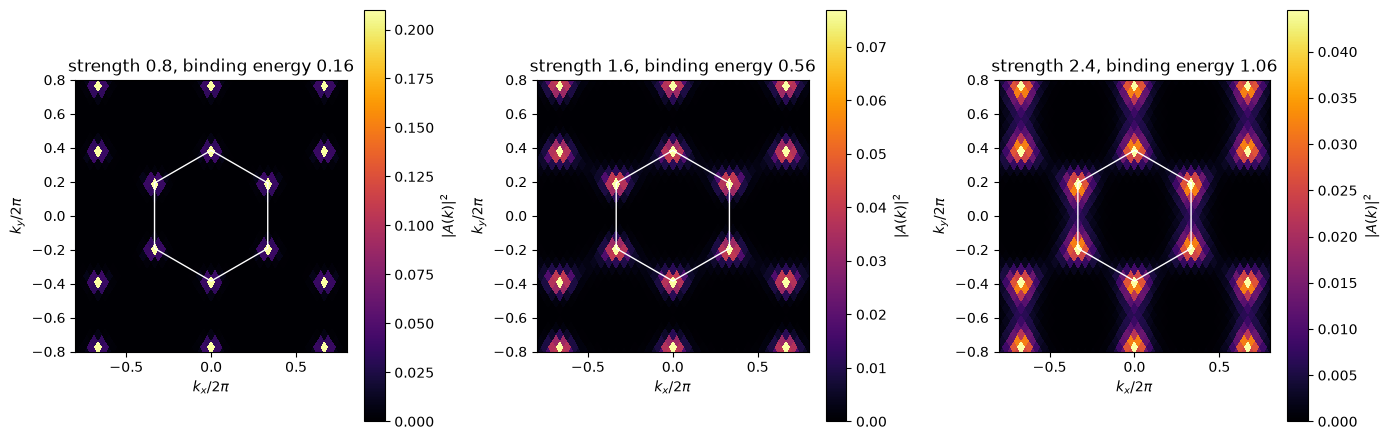

In [3]:
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_sublattice_imbalance(1.0) # a gapped two-band semiconductor
nk = 15 # k-mesh, a multiple of 3 so that it contains the K and K' points
b1,b2 = np.array(g.b1),np.array(g.b2) # reciprocal lattice vectors
Kc = 2./3.*b1 - 1./3.*b2 # a K point, a corner of the Brillouin zone
angles = np.linspace(0.,2.*np.pi,7) + np.arctan2(Kc[1],Kc[0])
hexagon = np.sqrt(Kc.dot(Kc))*np.array([np.cos(angles),np.sin(angles)])

fig,axs = plt.subplots(1,3,figsize=(14,4.5))
for ax,e2 in zip(axs,[0.8,1.6,2.4]): # three strengths of the Coulomb tail
    W = density_interaction(h,Vr=lambda r1,r2: e2/np.sqrt((r1-r2).dot(r1-r2)+0.25))
    bse = h.get_bse(V=W,nk=nk) # full (non-Tamm-Dancoff) BSE
    A = bse.amplitudes[0] # electron-hole amplitudes of the lowest exciton
    env = np.zeros(nk*nk)
    for m in range(len(A)): env[bse.pairs.kindex[m]] += np.abs(A[m])**2 # sum over bands
    env = env.reshape((nk,nk)) # the mesh is k = (i1,i2)/nk
    for s1 in [-2,-1,0,1]: # repeat the zone to show the valleys around it
        for s2 in [-2,-1,0,1]:
            i1 = (np.arange(nk+1)-0.5)/nk + s1 ; i2 = (np.arange(nk+1)-0.5)/nk + s2
            K1,K2 = np.meshgrid(i1,i2,indexing="ij")
            X = K1*b1[0] + K2*b2[0] ; Y = K1*b1[1] + K2*b2[1]
            im = ax.pcolormesh(X,Y,env,cmap="inferno",shading="flat",vmin=0.,vmax=env.max())
    ax.plot(hexagon[0],hexagon[1],c="white",lw=1)
    ax.set_xlim(-0.8,0.8) ; ax.set_ylim(-0.8,0.8) ; ax.set_aspect("equal")
    ax.set_xlabel(r"$k_x/2\pi$") ; ax.set_ylabel(r"$k_y/2\pi$")
    ax.set_title("strength %.1f, binding energy %.2f"%(e2,np.real(bse.get_binding_energies(n=1)[0])))
    fig.colorbar(im,ax=ax,label="$|A(k)|^2$")
plt.tight_layout()
plt.show()

### Exciton band structure
The bound electron-hole pair propagates with a center-of-mass momentum $Q$, and
`h.get_exciton_bands()` solves one Bethe-Salpeter equation per point of a path, giving the exciton
band structure $E_X(Q)$. The same call with `kernel="none"` gives the bare transitions, the
electron-hole continuum, and the exciton bands run below its edge by their binding energy all
along the path; how much they disperse says how heavy the exciton is.

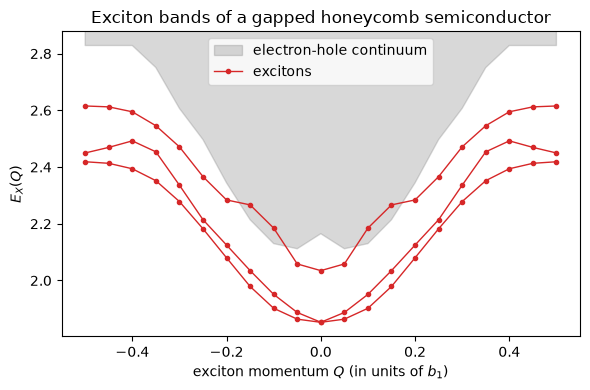

In [4]:
W = density_interaction(h,Vr=lambda r1,r2: 0.8/np.sqrt((r1-r2).dot(r1-r2)+0.25)) # Coulomb tail
nq,n = 21,3 # q-points along the path, and excitons kept at each of them
qvals = np.linspace(-0.5,0.5,nq) # straight through the zone center, in units of b1
opts = dict(qpath=[[q,0.,0.] for q in qvals],nk=8,n=n,V=W) # same setup for both calculations
qs,es = h.get_exciton_bands(**opts) # the excitons
qs0,es0 = h.get_exciton_bands(kernel="none",**opts) # the electron-hole continuum
es = es.reshape((nq,n)).real ; es0 = es0.reshape((nq,n)).real

plt.figure(figsize=(6,4))
plt.fill_between(qvals,es0[:,0],es0.max()+1.,color="gray",alpha=0.3,label="electron-hole continuum")
plt.plot(qvals,es,c="C3",marker="o",ms=3,lw=1)
plt.plot([],[],c="C3",marker="o",ms=3,lw=1,label="excitons")
plt.ylim(es.min()-0.05,es0.max()+0.05)
plt.xlabel("exciton momentum $Q$ (in units of $b_1$)") ; plt.ylabel("$E_X(Q)$")
plt.legend() ; plt.title("Exciton bands of a gapped honeycomb semiconductor")
plt.tight_layout()
plt.show()